In [1]:
#importar paquetes
#GUARDAR
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# =========================
# BLOQUE 0: Carga excel
# =========================
file_path = "Butanos a OSBL - Históricos 2024 2025.xlsx"

df = pd.read_excel(file_path, sheet_name="Data - C4s")

In [3]:
# =========================
# BLOQUE 1: Separar 2024 y 2025
# =========================
df_2024 = df.iloc[:, 0:2].copy()
df_2025 = df.iloc[:, 2:4].copy()

df_2024.columns = ["Fecha", "Flujo_OSBL"]
df_2025.columns = ["Fecha", "Flujo_OSBL"]

# Convertir fechas
df_2024["Fecha"] = pd.to_datetime(df_2024["Fecha"], format="%d-%b-%y %H:%M:%S", errors="coerce")
df_2025["Fecha"] = pd.to_datetime(df_2025["Fecha"], format="%d-%b-%y %H:%M:%S", errors="coerce")

In [4]:
# =========================
# BLOQUE 2: Merge vertical
# =========================
df_merged = pd.concat([df_2024, df_2025], axis=0)

df_merged = (
    df_merged
    .dropna(subset=["Fecha"])
    .sort_values("Fecha")
    .drop_duplicates(subset="Fecha")
    .set_index("Fecha")
)

In [5]:
df_merged.head()

,Flujo_OSBL
Fecha,
2024-01-01 00:00:00,1162.073209
2024-01-01 00:01:00,1199.041775
2024-01-01 00:02:00,1174.621478
2024-01-01 00:03:00,1220.203874
2024-01-01 00:04:00,1222.544311


In [6]:
# =========================
# BLOQUE 3: Suma con indentación de NaN
# =========================

# Convertir a numérico textos como "No Good Data For Calculation" = NaN
#columna auxiliar para Flujo_OSBL
df_merged["Flujo_OSBL_num"] = pd.to_numeric(df_merged["Flujo_OSBL"], errors="coerce")

# Identificar entradas problemáticas:
# 1) No numéricas (NaN)
# 2) Negativos
mask_problem = (
    df_merged["Flujo_OSBL_num"].isna() |
    (df_merged["Flujo_OSBL_num"] < 0)
)

# Crear columna suma condicional:
#df_merged["Flujo_Total_C3s"] = (
#   df_merged["Flujo_U110_num"] + df_merged["Flujo_Tanques_num"]
#)

# Indentar resultado de suma por NaN (entradas problemáticas)
df_merged.loc[mask_problem, "Flujo_OSBL_num"] = np.nan

In [7]:
# =========================
# BLOQUE 4: Preparar datos para graficar
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Convertir a numérico y forzar negativos a NaN
for col in ["Flujo_OSBL"]:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")
    df_merged.loc[df_merged[col] < 0, col] = np.nan

In [8]:
# =========================
# BLOQUE 5.0: Mediana por columna (vector independiente)
# =========================

# Asegurar numérico y negativos como NaN
df_merged["Flujo_OSBL"] = pd.to_numeric(df_merged["Flujo_OSBL"], errors="coerce")

df_merged.loc[df_merged["Flujo_OSBL"] < 0, "Flujo_OSBL"] = np.nan

# Medianas individuales
mediana_OSBL = df_merged["Flujo_OSBL"].median(skipna=True)

print("Mediana Flujo_OSBL:", mediana_OSBL)

Mediana Flujo_OSBL: 688.2439005691721


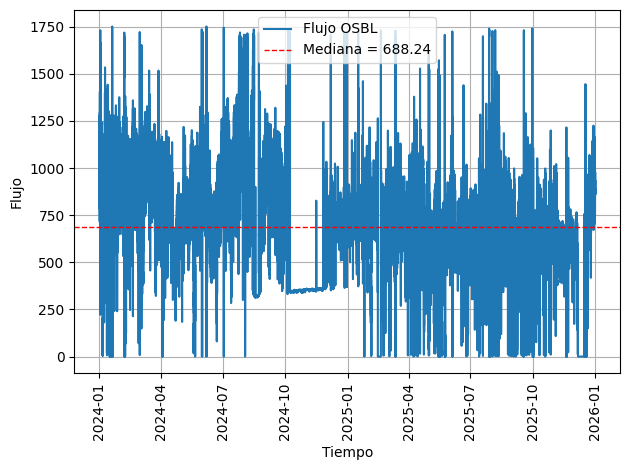

In [9]:
# =========================
# BLOQUE 5.1: Gráfico discontinuo Flujo OSBL
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_OSBL"], label="Flujo OSBL")

plt.axhline(mediana_OSBL, linestyle="--", linewidth=1, color='r',
            label=f"Mediana = {mediana_OSBL:.2f}")

plt.xlabel("Tiempo")
plt.ylabel("Flujo")
plt.xticks(rotation=90)
#plt.title("ACA EL TITULITO")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

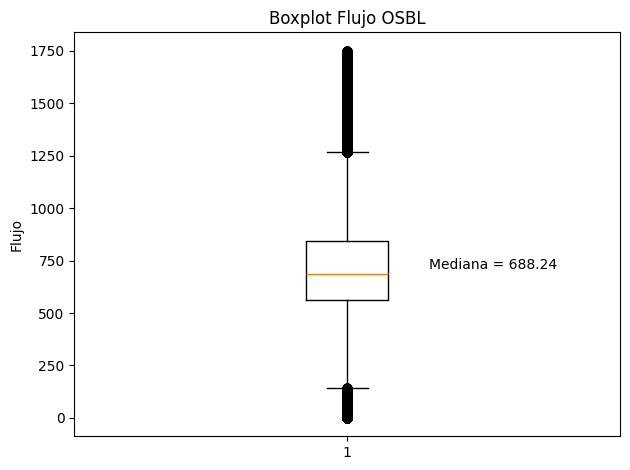

In [10]:
data_OSBL = df_merged["Flujo_OSBL"].dropna()

plt.boxplot(data_OSBL, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

plt.text(1.15, mediana_OSBL + 0.02*(ymax - ymin),
         f"Mediana = {mediana_OSBL:.2f}",
         verticalalignment='center')

plt.ylabel("Flujo")
plt.title("Boxplot Flujo OSBL")
plt.tight_layout()
plt.show()

In [11]:
columnas = ["Flujo_OSBL"]

# Asegurar formato numérico y negativos como NaN
for col in columnas:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")
    df_merged.loc[df_merged[col] < 0, col] = np.nan

# Crear columna año desde el índice temporal
df_merged["Año"] = df_merged.index.year

# Calcular medianas por año
medianas_por_año = df_merged.groupby("Año")[columnas].median()

print("Medianas por año:")
print(medianas_por_año)

Medianas por año:
      Flujo_OSBL
Año             
2024  803.486265
2025  634.559819
